# PROJET MACHINE LEARNING - ABALONE

## A.Présentation du Dataset


<div class="alert alert-block alert-info">

**Nom du dataset :** Abalone

**Lien UCI :** https://archive.ics.uci.edu/dataset/1/abalone

**Type de problème :** Régression

**Objectif :** prédire le nombre d’anneaux (*Rings*) d’un abalone à partir de mesures physiques, afin d’estimer son âge approximatif.

**Variable cible (Y) :** `Rings`  
(*L’âge approximatif est estimé par : Rings + 1.5*)

**Nombre d’observations :** 4177

**Nombre de variables :** 9 au total  
(8 variables explicatives + 1 variable cible)

**Description rapide des variables :**  
Le dataset contient :
- **Une variable catégorielle :**
  - `Sex` : sexe de l’abalone (`M`, `F`, `I` pour *infant*)
- **Des variables morphométriques continues (en mm) :**
  - `Length` : longueur maximale de la coquille  
  - `Diameter` : diamètre perpendiculaire à la longueur  
  - `Height` : hauteur avec la chair dans la coquille
- **Des variables de poids (en grammes) :**
  - `Whole_weight` : poids total  
  - `Shucked_weight` : poids de la chair  
  - `Viscera_weight` : poids des viscères (après saignée)  
  - `Shell_weight` : poids de la coquille après séchage
- **La variable cible :**
  - `Rings` : nombre d’anneaux, utilisé pour estimer l’âge

**Remarque :**  
Le dataset ne contient pas de valeurs manquantes. Il s’agit d’un problème de régression, car la variable cible `Rings` est une variable numérique entière.

</div>

## B. Exploration & Analyse des données

### Importation des données

In [29]:

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.base import clone

sns.set(style="whitegrid")
np.random.seed(42)

#fetch the Abalone dataset from the UCI Machine Learning Repository
from ucimlrepo import fetch_ucirepo 
abalone = fetch_ucirepo(id=1)  

### L'information globale du dataset

In [2]:
# Display basic information about the dataset
df_raw = abalone.data.original
# Display information about the DataFrame, including data types and non-null counts
print("Informations sur le DataFrame:", df_raw.info())
#Display types des variables
print("Types des variables:", df_raw.dtypes)
print("Shape:", df_raw.shape)
print("Colonnes:", df_raw.columns.tolist())
print("Valeurs manquantes par colonne:\n", df_raw.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 293.8 KB
Informations sur le DataFrame: None
Types des variables: Sex                   str
Length            float64
Diameter          float64
Height            float64
Whole_weight      float64
Shucked_weight    float64
Viscera_weight    float64
Shell_weight      float64
Rings               int64
dtype: object
Shape: (4177, 9)
Colonnes: ['Sex', 'Length', 


<div class="alert alert-block alert-info">
The Abalone dataset contains 4177 samples and 9 columns (8 features + 1 target). 

Shape: (4177, 9).

Features: `Sex`, `Length`, `Diameter`, `Height`, `Whole_weight`, `Shucked_weight`, `Viscera_weight`, `Shell_weight`.  

Target: `Rings` (nombre d’anneaux; âge approximatif ≈ Rings + 1.5).

Aperçu du dataframe chargé : colonnes et valeurs affichées dans `df_raw` ci‑dessus. Le dataset ne contient pas de valeurs manquantes.

- `df_raw.info()` confirme qu’il n’y a aucune valeur nulle, que la variable `Sex` est de type `object` et les autres colonnes sont numériques (`float64` à l’exception de `Rings` qui est entier). Cela facilitera l’encodage et la normalisation.

</div>

In [3]:
# Display summary statistics of the DataFrame
print("Summary statistics:", df_raw.describe())

Summary statistics:             Length     Diameter       Height  Whole_weight  Shucked_weight  \
count  4177.000000  4177.000000  4177.000000   4177.000000     4177.000000   
mean      0.523992     0.407881     0.139516      0.828742        0.359367   
std       0.120093     0.099240     0.041827      0.490389        0.221963   
min       0.075000     0.055000     0.000000      0.002000        0.001000   
25%       0.450000     0.350000     0.115000      0.441500        0.186000   
50%       0.545000     0.425000     0.140000      0.799500        0.336000   
75%       0.615000     0.480000     0.165000      1.153000        0.502000   
max       0.815000     0.650000     1.130000      2.825500        1.488000   

       Viscera_weight  Shell_weight        Rings  
count     4177.000000   4177.000000  4177.000000  
mean         0.180594      0.238831     9.933684  
std          0.109614      0.139203     3.224169  
min          0.000500      0.001500     1.000000  
25%          0.093500 

<div class="alert alert-block alert-info">

- Les statistiques descriptives (`df_raw.describe()`) montrent des variabilités importantes entre les poids : par exemple **Whole_weight** varie de 0.002 à 2.825 avec un écart‑type élevé (~0.76), indiquant des distributions fortement étirées. Les médianes sont bien inférieures aux maxima, suggérant des distributions asymétriques.

- L’âge variable `Rings` s’étend de 1 à 29, avec une moyenne autour de 9.9 ; il est donc nécessaire de vérifier si la distribution est équilibrée pour la régression.

- La colonne `Sex` compte trois modalités (`M`, `F`, `I`), ce qui impose un encodage catégoriel avant l’entraînement des modèles.

Ces éléments donnent un premier aperçu de la structure du jeu de données et orientent les étapes de prétraitement (encodage, normalisation, gestion de possible asymétrie ou d’outliers).
</div>

### Analyse des variables catégoriques

Categorical columns: ['Sex']

Column 'Sex':
  Unique values: <StringArray>
['M', 'F', 'I']
Length: 3, dtype: str
  Counts:
 Sex
M    1528
I    1342
F    1307
Name: count, dtype: int64
  Imbalance ratio (largest/total): 0.37


/var/folders/02/rg3c02cj0qb6c2v_pzlj32cr0000gn/T/ipykernel_86412/3106357604.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_raw.select_dtypes(include=['object','category']).columns.tolist()
/var/folders/02/rg3c02cj0qb6c2v_pzlj32cr0000gn/T/ipykernel_86412/3106357604.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='pastel')


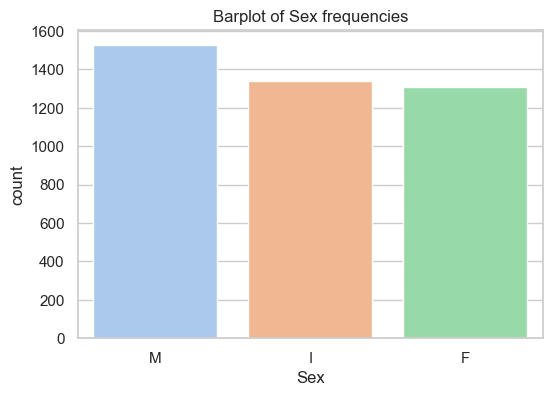

In [4]:
# Analyze categorical variables (Abalone has a 'Sex' column)
cat_cols = df_raw.select_dtypes(include=['object','category']).columns.tolist()
print("Categorical columns:", cat_cols)
for col in cat_cols:
    print(f"\nColumn '{col}':")
    print("  Unique values:", df_raw[col].unique())
    counts = df_raw[col].value_counts()
    print("  Counts:\n", counts)
    imbalance = counts.max() / counts.sum()
    print(f"  Imbalance ratio (largest/total): {imbalance:.2f}")
    
# Visualizations
if 'Sex' in cat_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(x=counts.index, y=counts.values, palette='pastel')
    plt.title('Barplot of Sex frequencies')
    plt.ylabel('count')
    plt.show()

<div class="alert alert-block alert-info">

La variable `Sex` comporte trois modalités (`M`, `F`, `I`) avec des effectifs relativement proches (1528, 1307 et 1342).  
La distribution est donc globalement équilibrée, même si la modalité `M` est légèrement majoritaire.  

Cette variable ne présente pas de déséquilibre majeur, mais comme il s’agit d’une variable catégorielle nominale
=> un encodage (Ici je vais utiliser One-Hot Encoding) sera nécessaire avant l’entraînement des modèles.

</div>

### Analyse de la variable cible `Rings`

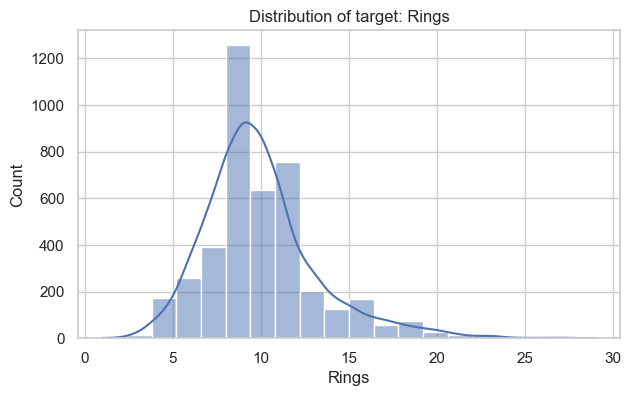

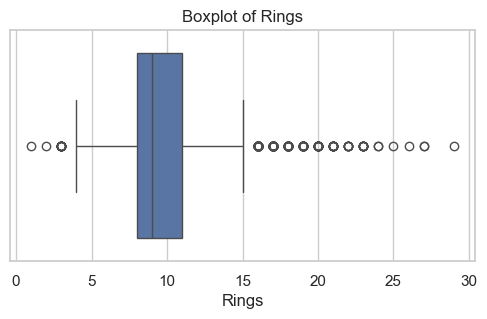

count    4177.000000
mean        9.933684
std         3.224169
min         1.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        29.000000
Name: Rings, dtype: float64
Skewness of Rings: 1.114101898355677


In [5]:
# Target analysis: Rings
plt.figure(figsize=(7,4))
sns.histplot(df_raw["Rings"], bins=20, kde=True)
plt.title("Distribution of target: Rings")
plt.xlabel("Rings")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,3))
sns.boxplot(x=df_raw["Rings"])
plt.title("Boxplot of Rings")
plt.show()

print(df_raw["Rings"].describe())
print("Skewness of Rings:", df_raw["Rings"].skew())

<div class="alert alert-block alert-info">

La variable cible <code>Rings</code> est centrée autour de 9 à 10 anneaux (médiane = 9, moyenne = 9.93), avec une étendue de 1 à 29.  
L’histogramme et la valeur de skewness (<code>1.11</code>) montrent une distribution asymétrique à droite, avec une queue étendue vers les valeurs élevées.  

Le boxplot met également en évidence plusieurs valeurs extrêmes, surtout pour les grands nombres d’anneaux.  
Ainsi, la régression reste pertinente, mais il faudra garder à l’esprit la présence d’asymétrie et d’outliers lors du prétraitement et de l’évaluation des modèles.

</div>

### Analyse des variables numériques explicatives

In [6]:
numeric_cols = df_raw.select_dtypes(include=["number"]).columns.tolist()
numeric_feature_cols = [col for col in numeric_cols if col != "Rings"]

print("Numeric feature columns:", numeric_feature_cols)
# Summary stats for numeric predictors
print(df_raw[numeric_feature_cols].describe().T)

Numeric feature columns: ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight']
                 count      mean       std     min     25%     50%    75%  \
Length          4177.0  0.523992  0.120093  0.0750  0.4500  0.5450  0.615   
Diameter        4177.0  0.407881  0.099240  0.0550  0.3500  0.4250  0.480   
Height          4177.0  0.139516  0.041827  0.0000  0.1150  0.1400  0.165   
Whole_weight    4177.0  0.828742  0.490389  0.0020  0.4415  0.7995  1.153   
Shucked_weight  4177.0  0.359367  0.221963  0.0010  0.1860  0.3360  0.502   
Viscera_weight  4177.0  0.180594  0.109614  0.0005  0.0935  0.1710  0.253   
Shell_weight    4177.0  0.238831  0.139203  0.0015  0.1300  0.2340  0.329   

                   max  
Length          0.8150  
Diameter        0.6500  
Height          1.1300  
Whole_weight    2.8255  
Shucked_weight  1.4880  
Viscera_weight  0.7600  
Shell_weight    1.0050  


<div class="alert alert-block alert-info">

  Les variables ne sont pas sur la même échelle : les mesures de taille `Length`, `Diameter`, `Height` ont des amplitudes plus faibles que les variables de poids, ce qui justifie de tester une normalisation au moment du prétraitement.

</div>

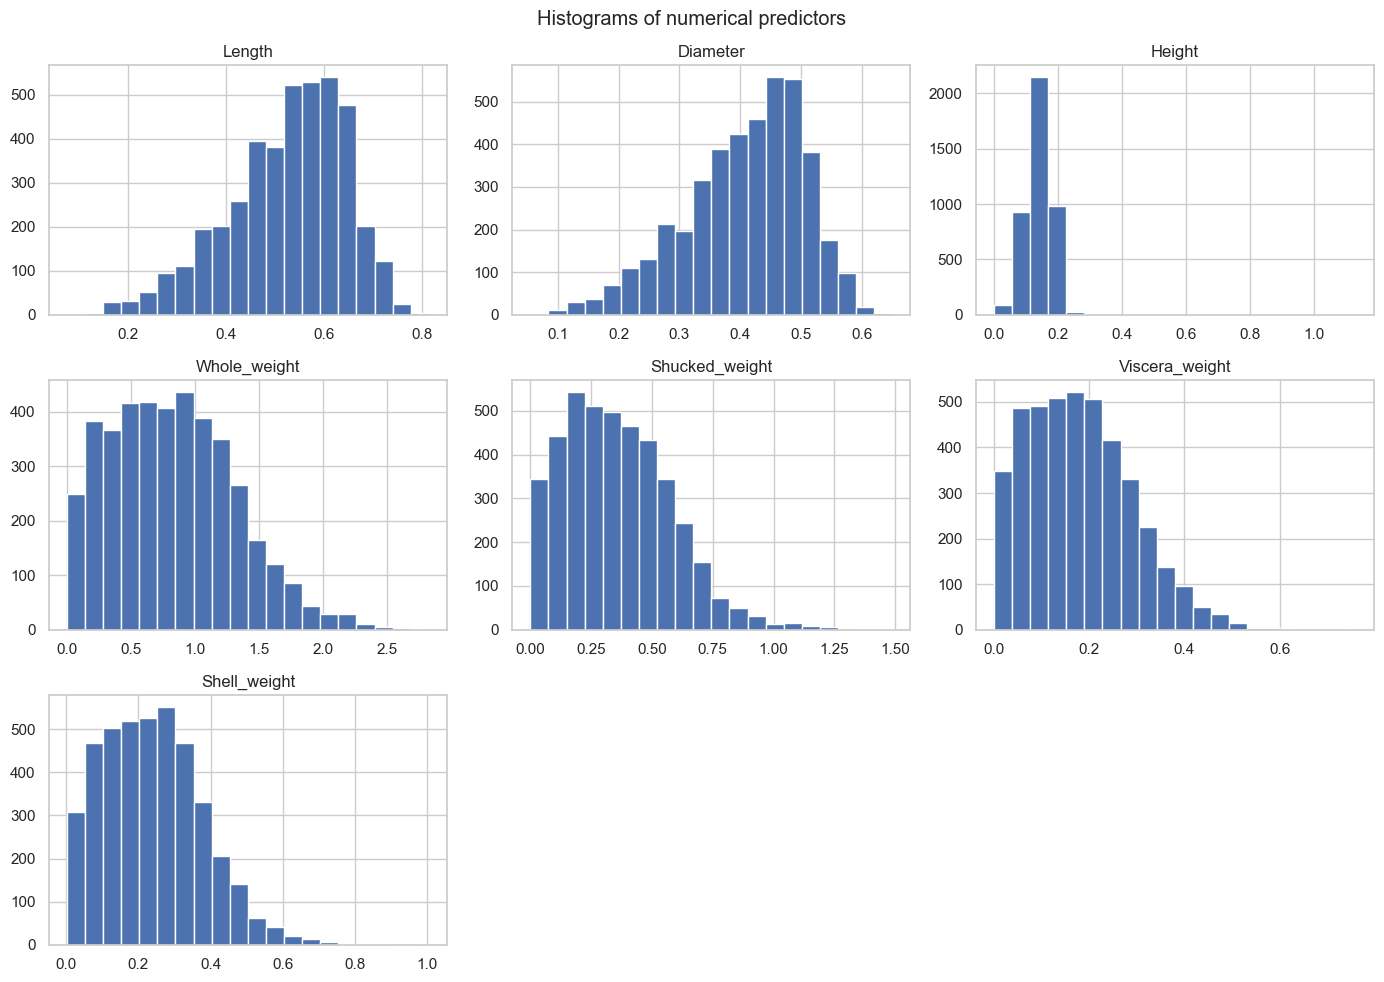

In [7]:
# Histograms
df_raw[numeric_feature_cols].hist(figsize=(14,10), bins=20)
plt.suptitle("Histograms of numerical predictors")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">

Les variables de `Length` et `Diameter` sont relativement bien réparties, tandis que `Height` semble contenir des valeurs extrêmes.  
Les variables de poids sont asymétriques à droite, avec des queues longues vers les grandes valeurs.  
</div>

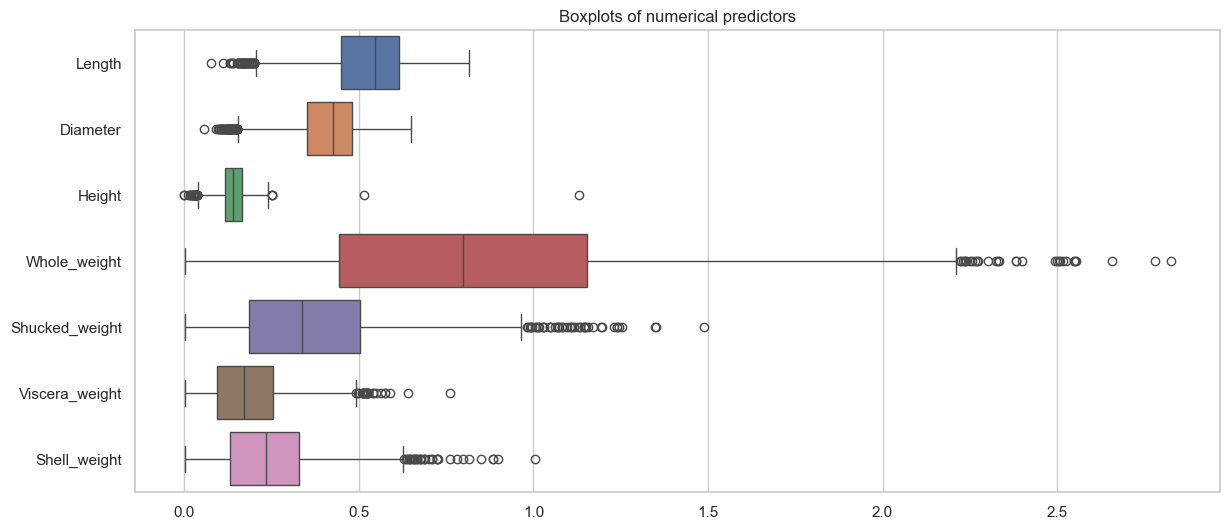

In [8]:
# Boxplots
plt.figure(figsize=(14,6))
sns.boxplot(data=df_raw[numeric_feature_cols], orient="h")
plt.title("Boxplots of numerical predictors")
plt.show()

<div class="alert alert-block alert-info">

Les boxplots montrent la présence de plusieurs valeurs extrêmes, surtout pour `Height` et les variables de poids.  
Les outliers sont particulièrement marqués à droite pour `Whole_weight`, `Shucked_weight`, `Viscera_weight` et `Shell_weight`, ce qui confirme l’existence de distributions étendues vers les grandes valeurs.  
La variable `Height` a une valeur au minimum est très proche de 0 , et quelques valeurs très élevées.  
Ces résultats justifient une vérification spécifique des outliers avant de comparer les différentes versions de preprocessing.

</div>

In [9]:
# Skewness
skewness = df_raw[numeric_feature_cols].skew().sort_values(ascending=False)
print("Skewness of numerical predictors:\n", skewness)

Skewness of numerical predictors:
 Height            3.128817
Shucked_weight    0.719098
Shell_weight      0.620927
Viscera_weight    0.591852
Whole_weight      0.530959
Diameter         -0.609198
Length           -0.639873
dtype: float64


<div class="alert alert-block alert-info">

Les coefficients de skewness confirment que plusieurs variables numériques ne suivent pas une distribution symétrique.  

`Height` présente une forte asymétrie à droite (3.13), ce qui indique une distribution très dissymétrique avec quelques valeurs extrêmes.  

Les variables de poids montrent également une asymétrie positive modérée ()`Whole_weight`, `Shucked_weight`, `Viscera_weight`, `Shell_weight`), tandis que `Length` et `Diameter` ont une légère asymétrie à gauche.  

</div>

### Détection des outliers

In [10]:
# IQR method

outlier_results = []

for col in numeric_feature_cols:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (df_raw[col] < lower_bound) | (df_raw[col] > upper_bound)
    n_outliers = outlier_mask.sum()
    pct_outliers = (n_outliers / len(df_raw)) * 100
    
    outlier_results.append({
        "Variable": col,
        "Q1": round(Q1, 4),
        "Q3": round(Q3, 4),
        "IQR": round(IQR, 4),
        "Lower_bound": round(lower_bound, 4),
        "Upper_bound": round(upper_bound, 4),
        "N_outliers": int(n_outliers),
        "Pct_outliers": round(pct_outliers, 2)
    })

outlier_df = pd.DataFrame(outlier_results).sort_values(by="Pct_outliers", ascending=False)

print("Outlier summary by variable (IQR method):")
display(outlier_df)

Outlier summary by variable (IQR method):


,Variable,Q1,Q3,IQR,Lower_bound,Upper_bound,N_outliers,Pct_outliers
1,Diameter,0.3500,0.480,0.1300,0.1550,0.6750,59,1.41
0,Length,0.4500,0.615,0.1650,0.2025,0.8625,49,1.17
4,Shucked_weight,0.1860,0.502,0.3160,-0.2880,0.9760,48,1.15
6,Shell_weight,0.1300,0.329,0.1990,-0.1685,0.6275,35,0.84
3,Whole_weight,0.4415,1.153,0.7115,-0.6258,2.2202,30,0.72
2,Height,0.1150,0.165,0.0500,0.0400,0.2400,29,0.69
5,Viscera_weight,0.0935,0.253,0.1595,-0.1458,0.4922,26,0.62


<div class="alert alert-block alert-info">

Toutes les variables explicatives numériques contiennent un faible pourcentage de valeurs extrêmes.
Les variables les plus concernées sont `Diameter` (1.41 %), `Length` (1.17 %) et `Shucked_weight` (1.15 %).

Même si certaines variables, comme `Height`, présentaient une forte asymétrie, leur proportion d’outliers au sens de l’IQR reste limitée (0.69 %).  
Globalement, le dataset ne semble donc pas fortement perturbé par des valeurs extrêmes.


</div>

### Corrélations

<Figure size 1000x800 with 0 Axes>

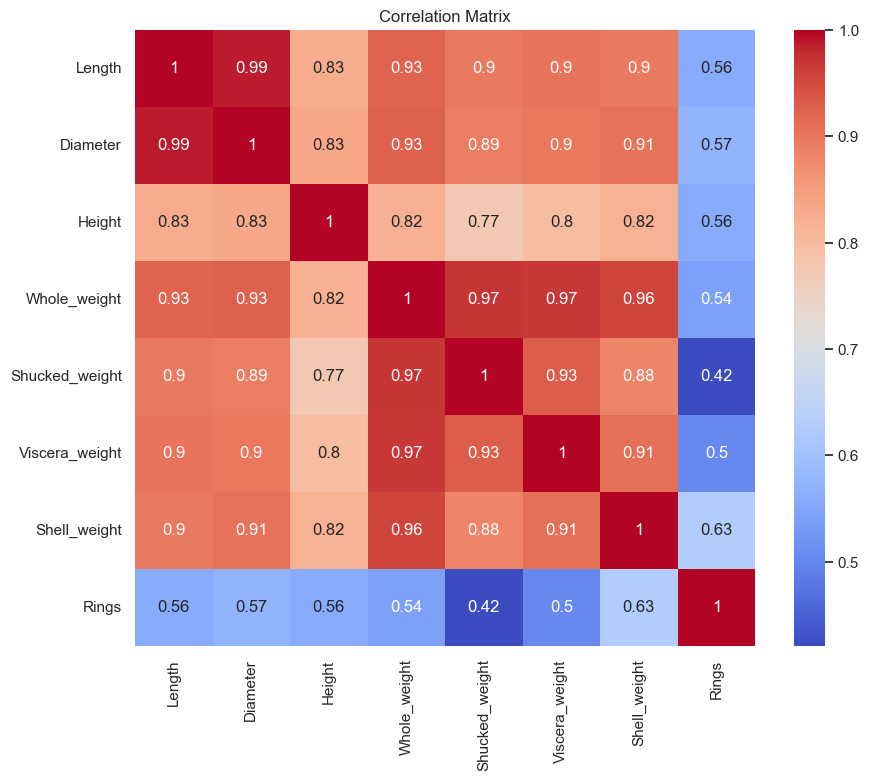

In [11]:
plt.figure(figsize=(10,8))
plt.figure(figsize=(10,8))
sns.heatmap(df_raw.drop(columns='Sex').corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

<div class="alert alert-block alert-info">

La matrice de corrélation montre de fortes corrélations entre plusieurs variables explicatives numériques.  
En particulier, `Length` et `Diameter` sont presque parfaitement corrélées (r ≈ 0.99<), et les variables de poids sont également très corrélées entre elles (r ≈ 0.88 à 0.97).  

Cela suggère une forte redondance d’information et donc un risque de multicolinéarité pour les modèles linéaires.  
Concernant la cible `Rings`, les corrélations restent positives mais modérées.

Ainsi, aucune variable seule ne semble suffisante pour prédire parfaitement `Rings`, cela justifie l’utilisation de modèles multivariés.

</div>

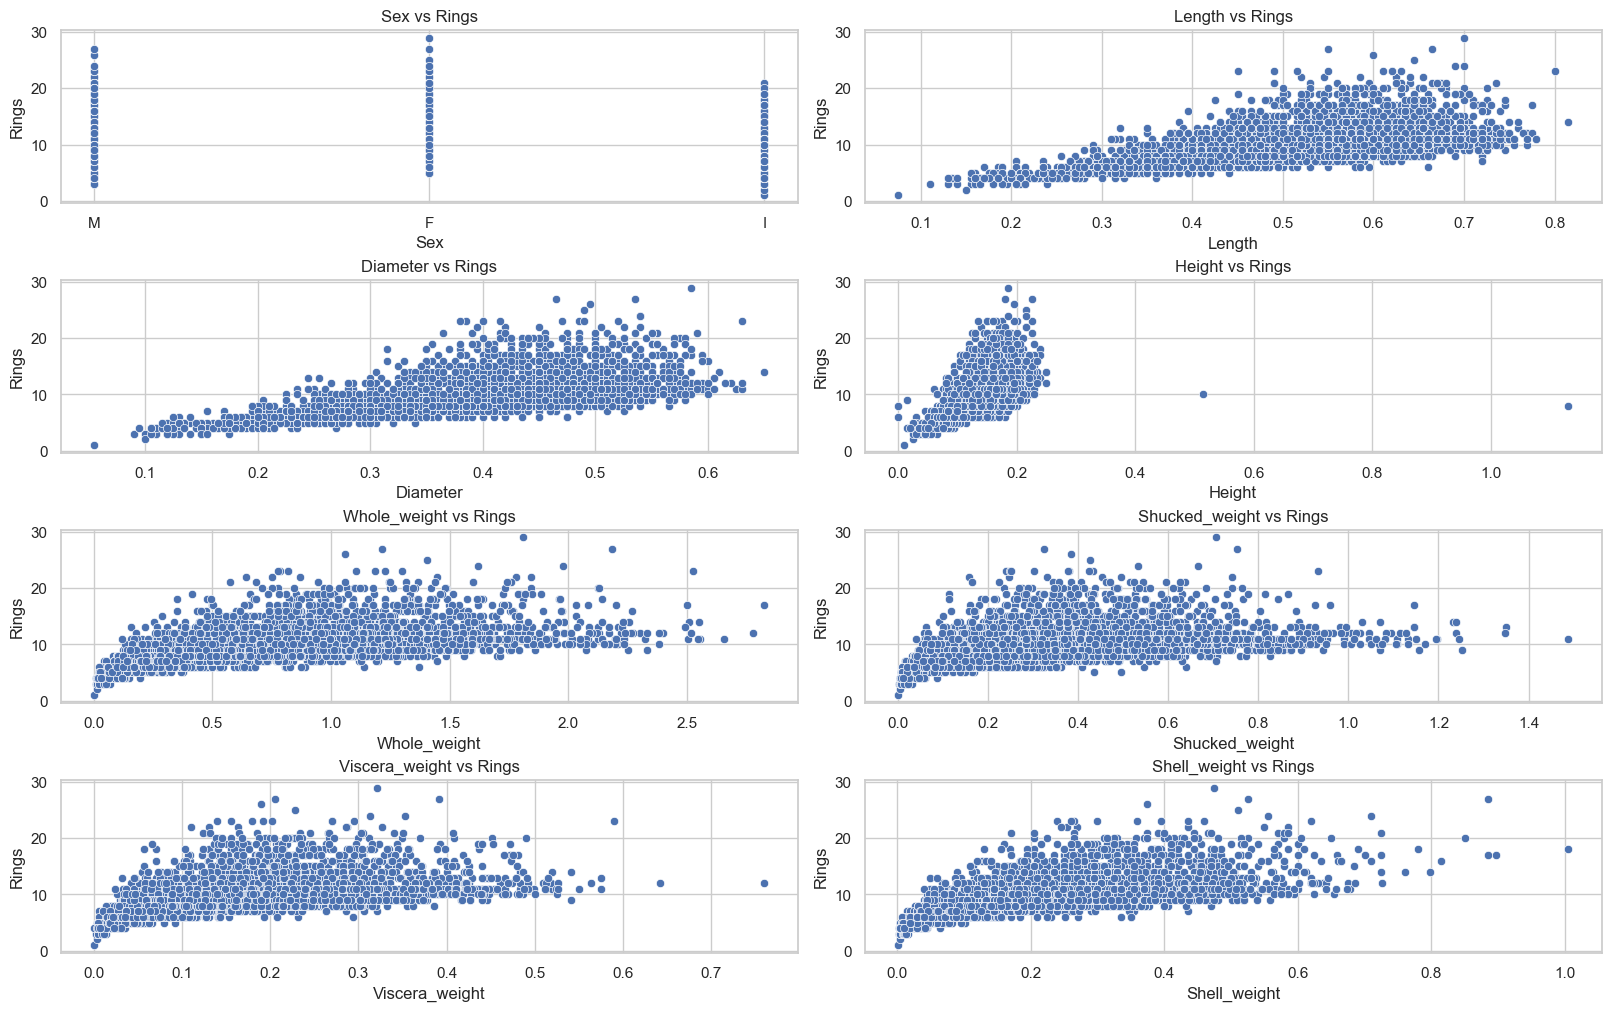

In [12]:
# scatterplots of every feature vs. the target (Rings) in the Abalone dataset
features = [c for c in df_raw.columns if c != "Rings"]
n_features = len(features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for i, feature in enumerate(features):
    sns.scatterplot(x=df_raw[feature], y=df_raw["Rings"], ax=axes[i])
    axes[i].set_title(f"{feature} vs Rings")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Rings")

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.show()

<div class="alert alert-block alert-info">

On observe des points atypiques, notamment pour `Height`, ce qui reste cohérent avec l’analyse précédente des valeurs extrêmes.  

Les nuages de points confirment une relation globalement positive entre les variables numériques et la cible `Rings` : lorsque les mesures de taille ou de poids augmentent, le nombre d’anneaux tend aussi à augmenter. 

Cependant, cette relation n’est pas strictement linéaire et la dispersion devient plus importante pour les grandes valeurs, ce qui suggère une variabilité croissante et des relations potentiellement non linéaires.



</div>

### Problèmes de formatage possibles

<div class="alert alert-block alert-success">

### Vérification des problèmes de formatage

L’analyse détaillée du formatage des données a permis de vérifier les points suivants :

- **Espaces invisibles** :  
    Les valeurs uniques de la colonne catégorielle `Sex` ont été inspectées pour détecter d’éventuels espaces en début ou fin de chaîne.  
    Résultat : aucune valeur ne contient d’espace invisible, et le nettoyage `.str.strip()` ne modifie pas le nombre de modalités.

- **Colonnes mal encodées / Nombres stockés comme string** :  
    Toutes les colonnes numériques (`Length`, `Diameter`, `Height`, `Whole_weight`, `Shucked_weight`, `Viscera_weight`, `Shell_weight`, `Rings`) sont bien de type numérique (`float64` ou `int64`).  
    La tentative de conversion avec `pd.to_numeric(errors='coerce')` n’a révélé aucune valeur non convertible.

- **Caractères spéciaux** :  
    Les colonnes numériques ne contiennent pas de caractères spéciaux autres que les chiffres, le point décimal et le signe négatif.  

- **Problèmes d’encodage (caractères non-ASCII)** :  
    Les colonnes de type `object` (`Sex`) ne contiennent pas de caractères non-ASCII.

**Conclusion** :  
Aucun problème de formatage n’a été détecté dans le dataset Abalone :  

</div>

## C. Preprocessing

<div class="alert alert-block alert-info">

Dans cette section, je prépare plusieurs versions du dataset afin de comparer l’impact du preprocessing sur les performances des modèles.  
Conformément aux consignes, je travaille toujours sur des copies du dataset initial, sans jamais écraser la version brute.

Pour la variable `Sex` possède trois modalités (`M`, `F`, `I`) : un <b>One-Hot Encoding</b> est donc plus approprié qu’un label encoding, afin d’éviter d’introduire un ordre numerique entre les catégories.  

Ensuit je vais comparer trois stratégies : sans normalisation, avec normalisation, et avec normalisation suivie d’une PCA.
À ce stade, les objets nécessaires au preprocessing sont seulement définis.  
L’application effective de ces transformations sera réalisée après la séparation train/test dans la section suivante.


</div>

In [13]:
# Keep the raw dataset unchanged
df_original_abalone = df_raw.copy(deep=True)

# Target and feature groups
target_column_name_abalone = "Rings"

categorical_feature_columns_abalone = ["Sex"]

numerical_feature_columns_abalone = [
    "Length",
    "Diameter",
    "Height",
    "Whole_weight",
    "Shucked_weight",
    "Viscera_weight",
    "Shell_weight"
]

all_feature_columns_abalone = [
    col for col in df_original_abalone.columns
    if col != target_column_name_abalone
]

print("Target column:", target_column_name_abalone)
print("Categorical feature columns:", categorical_feature_columns_abalone)
print("Numerical feature columns:", numerical_feature_columns_abalone)
print("All feature columns:", all_feature_columns_abalone)

Target column: Rings
Categorical feature columns: ['Sex']
Numerical feature columns: ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight']
All feature columns: ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight']


In [14]:


def preprocess_abalone_after_split(
    X_train_dataframe,
    X_test_dataframe,
    categorical_columns,
    numerical_columns,
    apply_scaling=False,
    apply_pca=False,
    pca_variance_threshold=0.95
):
    # Copy to avoid modifying original split data
    X_train_processed_abalone = X_train_dataframe.copy()
    X_test_processed_abalone = X_test_dataframe.copy()

    # 1) One-Hot Encoding
    X_train_processed_abalone = pd.get_dummies(
        X_train_processed_abalone,
        columns=categorical_columns,
        dtype=int
    )
    X_test_processed_abalone = pd.get_dummies(
        X_test_processed_abalone,
        columns=categorical_columns,
        dtype=int
    )

    # Align columns between train and test
    X_train_processed_abalone, X_test_processed_abalone = X_train_processed_abalone.align(
        X_test_processed_abalone,
        join="left",
        axis=1,
        fill_value=0
    )

    fitted_scaler_abalone = None
    fitted_pca_abalone = None

    # 2) Scaling only on numerical columns, fitted on train only
    if apply_scaling:
        fitted_scaler_abalone = StandardScaler()
        X_train_processed_abalone[numerical_columns] = fitted_scaler_abalone.fit_transform(
            X_train_processed_abalone[numerical_columns]
        )
        X_test_processed_abalone[numerical_columns] = fitted_scaler_abalone.transform(
            X_test_processed_abalone[numerical_columns]
        )

    # 3) PCA on the fully processed matrix, fitted on train only
    if apply_pca:
        fitted_pca_abalone = PCA(n_components=pca_variance_threshold)
        X_train_processed_abalone = fitted_pca_abalone.fit_transform(X_train_processed_abalone)
        X_test_processed_abalone = fitted_pca_abalone.transform(X_test_processed_abalone)

    return (
        X_train_processed_abalone,
        X_test_processed_abalone,
        fitted_scaler_abalone,
        fitted_pca_abalone
    )

<div class="alert alert-block alert-info">
For predictive performance, keeping all dummies is acceptable here; but for stricter linear-model identifiability, one category should be dropped.
</div>

## D. Séparation des données

<div class="alert alert-block alert-info">
Dans cette section, je sépare d’abord le dataset brut en variables explicatives (X) et variable cible (y), puis je crée trois découpages train/test différents : 80/20, 70/30 et 60/40, conformément aux consignes.

Le preprocessing n’est appliqué qu’après la séparation des données, afin d’éviter toute fuite d’information (data leakage). Les transformations apprennent donc leurs paramètres uniquement sur le jeu d’entraînement, puis sont appliquées au jeu de test.

Pour chaque split, je prépare ensuite trois versions des données :
- sans normalisation,
- avec normalisation,
- avec normalisation suivie d’une PCA.

Cette organisation permet une comparaison méthodologiquement rigoureuse entre les différents découpages et les différentes stratégies de preprocessing.
</div>

### Séparation x et y à partir du dataset brut

In [15]:
# Split X / y from the raw dataset
X_features_abalone = df_original_abalone.drop(columns=target_column_name_abalone)
y_target_abalone = df_original_abalone[target_column_name_abalone]

print("X_features_abalone shape:", X_features_abalone.shape)
print("y_target_abalone shape:", y_target_abalone.shape)

X_features_abalone shape: (4177, 8)
y_target_abalone shape: (4177,)


### Création 3 splits pour 3 stratégies:

In [16]:
# Split 80 / 20
X_train_80_20_abalone, X_test_80_20_abalone, y_train_80_20_abalone, y_test_80_20_abalone = train_test_split(
    X_features_abalone,
    y_target_abalone,
    test_size=0.20,
    random_state=42
)

# Split 70 / 30
X_train_70_30_abalone, X_test_70_30_abalone, y_train_70_30_abalone, y_test_70_30_abalone = train_test_split(
    X_features_abalone,
    y_target_abalone,
    test_size=0.30,
    random_state=42
)

# Split 60 / 40
X_train_60_40_abalone, X_test_60_40_abalone, y_train_60_40_abalone, y_test_60_40_abalone = train_test_split(
    X_features_abalone,
    y_target_abalone,
    test_size=0.40,
    random_state=42
)

# Store the raw splits in a dictionary for easier inspection
raw_train_test_splits_abalone = {
    "80/20": {
        "X_train": X_train_80_20_abalone,
        "X_test": X_test_80_20_abalone,
        "y_train": y_train_80_20_abalone,
        "y_test": y_test_80_20_abalone
    },
    "70/30": {
        "X_train": X_train_70_30_abalone,
        "X_test": X_test_70_30_abalone,
        "y_train": y_train_70_30_abalone,
        "y_test": y_test_70_30_abalone
    },
    "60/40": {
        "X_train": X_train_60_40_abalone,
        "X_test": X_test_60_40_abalone,
        "y_train": y_train_60_40_abalone,
        "y_test": y_test_60_40_abalone
    }
}

print("Raw train/test splits:")
for split_name, split_data in raw_train_test_splits_abalone.items():
    print(f"\n{split_name} split:")
    print(" - X_train shape:", split_data["X_train"].shape)
    print(" - X_test shape:", split_data["X_test"].shape)
    print(" - y_train shape:", split_data["y_train"].shape)
    print(" - y_test shape:", split_data["y_test"].shape)

Raw train/test splits:

80/20 split:
 - X_train shape: (3341, 8)
 - X_test shape: (836, 8)
 - y_train shape: (3341,)
 - y_test shape: (836,)

70/30 split:
 - X_train shape: (2923, 8)
 - X_test shape: (1254, 8)
 - y_train shape: (2923,)
 - y_test shape: (1254,)

60/40 split:
 - X_train shape: (2506, 8)
 - X_test shape: (1671, 8)
 - y_train shape: (2506,)
 - y_test shape: (1671,)


### Préparer les 3 versions après split 


In [17]:
def prepare_three_versions_for_one_split_abalone(
    X_train_dataframe,
    X_test_dataframe,
    categorical_columns,
    numerical_columns
):
    # Version 1: no scaling
    X_train_no_scaling_abalone, X_test_no_scaling_abalone, _, _ = preprocess_abalone_after_split(
        X_train_dataframe=X_train_dataframe,
        X_test_dataframe=X_test_dataframe,
        categorical_columns=categorical_columns,
        numerical_columns=numerical_columns,
        apply_scaling=False,
        apply_pca=False
    )

    # Version 2: with scaling
    X_train_with_scaling_abalone, X_test_with_scaling_abalone, fitted_scaler_abalone, _ = preprocess_abalone_after_split(
        X_train_dataframe=X_train_dataframe,
        X_test_dataframe=X_test_dataframe,
        categorical_columns=categorical_columns,
        numerical_columns=numerical_columns,
        apply_scaling=True,
        apply_pca=False
    )

    # Version 3: with scaling + PCA
    (
        X_train_with_scaling_pca_abalone,
        X_test_with_scaling_pca_abalone,
        fitted_scaler_for_pca_abalone,
        fitted_pca_abalone
    ) = preprocess_abalone_after_split(
        X_train_dataframe=X_train_dataframe,
        X_test_dataframe=X_test_dataframe,
        categorical_columns=categorical_columns,
        numerical_columns=numerical_columns,
        apply_scaling=True,
        apply_pca=True
    )

    return {
        "no_scaling": {
            "X_train": X_train_no_scaling_abalone,
            "X_test": X_test_no_scaling_abalone,
            "scaler": None,
            "pca": None
        },
        "with_scaling": {
            "X_train": X_train_with_scaling_abalone,
            "X_test": X_test_with_scaling_abalone,
            "scaler": fitted_scaler_abalone,
            "pca": None
        },
        "with_scaling_pca": {
            "X_train": X_train_with_scaling_pca_abalone,
            "X_test": X_test_with_scaling_pca_abalone,
            "scaler": fitted_scaler_for_pca_abalone,
            "pca": fitted_pca_abalone
        }
    }

#### Appliquer le preprocessing

In [18]:

prepared_dataset_versions_80_20_abalone = prepare_three_versions_for_one_split_abalone(
    X_train_dataframe=X_train_80_20_abalone,
    X_test_dataframe=X_test_80_20_abalone,
    categorical_columns=categorical_feature_columns_abalone,
    numerical_columns=numerical_feature_columns_abalone
)

prepared_dataset_versions_70_30_abalone = prepare_three_versions_for_one_split_abalone(
    X_train_dataframe=X_train_70_30_abalone,
    X_test_dataframe=X_test_70_30_abalone,
    categorical_columns=categorical_feature_columns_abalone,
    numerical_columns=numerical_feature_columns_abalone
)

prepared_dataset_versions_60_40_abalone = prepare_three_versions_for_one_split_abalone(
    X_train_dataframe=X_train_60_40_abalone,
    X_test_dataframe=X_test_60_40_abalone,
    categorical_columns=categorical_feature_columns_abalone,
    numerical_columns=numerical_feature_columns_abalone
)

print("Prepared preprocessing versions:")
for split_name, prepared_versions in {
    "80/20": prepared_dataset_versions_80_20_abalone,
    "70/30": prepared_dataset_versions_70_30_abalone,
    "60/40": prepared_dataset_versions_60_40_abalone
}.items():
    print(f"\n{split_name}")
    for version_name, version_data in prepared_versions.items():
        print(
            f" - {version_name}: "
            f"X_train {version_data['X_train'].shape}, "
            f"X_test {version_data['X_test'].shape}"
        )

Prepared preprocessing versions:

80/20
 - no_scaling: X_train (3341, 10), X_test (836, 10)
 - with_scaling: X_train (3341, 10), X_test (836, 10)
 - with_scaling_pca: X_train (3341, 4), X_test (836, 4)

70/30
 - no_scaling: X_train (2923, 10), X_test (1254, 10)
 - with_scaling: X_train (2923, 10), X_test (1254, 10)
 - with_scaling_pca: X_train (2923, 4), X_test (1254, 4)

60/40
 - no_scaling: X_train (2506, 10), X_test (1671, 10)
 - with_scaling: X_train (2506, 10), X_test (1671, 10)
 - with_scaling_pca: X_train (2506, 4), X_test (1671, 4)


In [19]:
# =========================================
# Unpack explicit variables (clear naming, easier for later sections)
# =========================================

# ----- 80/20 -----
X_train_80_20_no_scaling_abalone = prepared_dataset_versions_80_20_abalone["no_scaling"]["X_train"]
X_test_80_20_no_scaling_abalone = prepared_dataset_versions_80_20_abalone["no_scaling"]["X_test"]

X_train_80_20_with_scaling_abalone = prepared_dataset_versions_80_20_abalone["with_scaling"]["X_train"]
X_test_80_20_with_scaling_abalone = prepared_dataset_versions_80_20_abalone["with_scaling"]["X_test"]
fitted_scaler_80_20_abalone = prepared_dataset_versions_80_20_abalone["with_scaling"]["scaler"]

X_train_80_20_with_scaling_pca_abalone = prepared_dataset_versions_80_20_abalone["with_scaling_pca"]["X_train"]
X_test_80_20_with_scaling_pca_abalone = prepared_dataset_versions_80_20_abalone["with_scaling_pca"]["X_test"]
fitted_scaler_pca_80_20_abalone = prepared_dataset_versions_80_20_abalone["with_scaling_pca"]["scaler"]
fitted_pca_80_20_abalone = prepared_dataset_versions_80_20_abalone["with_scaling_pca"]["pca"]

# ----- 70/30 -----
X_train_70_30_no_scaling_abalone = prepared_dataset_versions_70_30_abalone["no_scaling"]["X_train"]
X_test_70_30_no_scaling_abalone = prepared_dataset_versions_70_30_abalone["no_scaling"]["X_test"]

X_train_70_30_with_scaling_abalone = prepared_dataset_versions_70_30_abalone["with_scaling"]["X_train"]
X_test_70_30_with_scaling_abalone = prepared_dataset_versions_70_30_abalone["with_scaling"]["X_test"]
fitted_scaler_70_30_abalone = prepared_dataset_versions_70_30_abalone["with_scaling"]["scaler"]

X_train_70_30_with_scaling_pca_abalone = prepared_dataset_versions_70_30_abalone["with_scaling_pca"]["X_train"]
X_test_70_30_with_scaling_pca_abalone = prepared_dataset_versions_70_30_abalone["with_scaling_pca"]["X_test"]
fitted_scaler_pca_70_30_abalone = prepared_dataset_versions_70_30_abalone["with_scaling_pca"]["scaler"]
fitted_pca_70_30_abalone = prepared_dataset_versions_70_30_abalone["with_scaling_pca"]["pca"]

# ----- 60/40 -----
X_train_60_40_no_scaling_abalone = prepared_dataset_versions_60_40_abalone["no_scaling"]["X_train"]
X_test_60_40_no_scaling_abalone = prepared_dataset_versions_60_40_abalone["no_scaling"]["X_test"]

X_train_60_40_with_scaling_abalone = prepared_dataset_versions_60_40_abalone["with_scaling"]["X_train"]
X_test_60_40_with_scaling_abalone = prepared_dataset_versions_60_40_abalone["with_scaling"]["X_test"]
fitted_scaler_60_40_abalone = prepared_dataset_versions_60_40_abalone["with_scaling"]["scaler"]

X_train_60_40_with_scaling_pca_abalone = prepared_dataset_versions_60_40_abalone["with_scaling_pca"]["X_train"]
X_test_60_40_with_scaling_pca_abalone = prepared_dataset_versions_60_40_abalone["with_scaling_pca"]["X_test"]
fitted_scaler_pca_60_40_abalone = prepared_dataset_versions_60_40_abalone["with_scaling_pca"]["scaler"]
fitted_pca_60_40_abalone = prepared_dataset_versions_60_40_abalone["with_scaling_pca"]["pca"]

In [21]:
# =========================================
# Summary table of all prepared datasets
# =========================================

prepared_datasets_summary_abalone = pd.DataFrame({
    "Dataset_name": [
        "X_train_80_20_no_scaling_abalone",
        "X_train_80_20_with_scaling_abalone",
        "X_train_80_20_with_scaling_pca_abalone",
        "X_train_70_30_no_scaling_abalone",
        "X_train_70_30_with_scaling_abalone",
        "X_train_70_30_with_scaling_pca_abalone",
        "X_train_60_40_no_scaling_abalone",
        "X_train_60_40_with_scaling_abalone",
        "X_train_60_40_with_scaling_pca_abalone"
    ],
    "Shape": [
        X_train_80_20_no_scaling_abalone.shape,
        X_train_80_20_with_scaling_abalone.shape,
        X_train_80_20_with_scaling_pca_abalone.shape,
        X_train_70_30_no_scaling_abalone.shape,
        X_train_70_30_with_scaling_abalone.shape,
        X_train_70_30_with_scaling_pca_abalone.shape,
        X_train_60_40_no_scaling_abalone.shape,
        X_train_60_40_with_scaling_abalone.shape,
        X_train_60_40_with_scaling_pca_abalone.shape
    ]
})

display(prepared_datasets_summary_abalone)

# Optional: inspect PCA retained dimensions
for split_name, fitted_pca_current in {
    "80/20": fitted_pca_80_20_abalone,
    "70/30": fitted_pca_70_30_abalone,
    "60/40": fitted_pca_60_40_abalone
}.items():
    if fitted_pca_current is not None:
        print(f"{split_name} - PCA components kept:", fitted_pca_current.n_components_)
        print(f"{split_name} - Explained variance ratio sum:", fitted_pca_current.explained_variance_ratio_.sum())
        print()

,Dataset_name,Shape
0,X_train_80_20_no_scaling_abalone,"(3341, 10)"
1,X_train_80_20_with_scaling_abalone,"(3341, 10)"
2,X_train_80_20_with_scaling_pca_abalone,"(3341, 4)"
3,X_train_70_30_no_scaling_abalone,"(2923, 10)"
4,X_train_70_30_with_scaling_abalone,"(2923, 10)"
5,X_train_70_30_with_scaling_pca_abalone,"(2923, 4)"
6,X_train_60_40_no_scaling_abalone,"(2506, 10)"
7,X_train_60_40_with_scaling_abalone,"(2506, 10)"
8,X_train_60_40_with_scaling_pca_abalone,"(2506, 4)"


80/20 - PCA components kept: 4
80/20 - Explained variance ratio sum: 0.9524014716177657

70/30 - PCA components kept: 4
70/30 - Explained variance ratio sum: 0.952720262604851

60/40 - PCA components kept: 4
60/40 - Explained variance ratio sum: 0.9515150592275331



In [22]:
# =========================================
# Group all prepared datasets for the next sections
# =========================================

prepared_comparison_datasets_by_split_and_version_abalone = {
    "80/20": {
        "no_scaling": (
            X_train_80_20_no_scaling_abalone,
            X_test_80_20_no_scaling_abalone,
            y_train_80_20_abalone,
            y_test_80_20_abalone
        ),
        "with_scaling": (
            X_train_80_20_with_scaling_abalone,
            X_test_80_20_with_scaling_abalone,
            y_train_80_20_abalone,
            y_test_80_20_abalone
        ),
        "with_scaling_pca": (
            X_train_80_20_with_scaling_pca_abalone,
            X_test_80_20_with_scaling_pca_abalone,
            y_train_80_20_abalone,
            y_test_80_20_abalone
        )
    },
    "70/30": {
        "no_scaling": (
            X_train_70_30_no_scaling_abalone,
            X_test_70_30_no_scaling_abalone,
            y_train_70_30_abalone,
            y_test_70_30_abalone
        ),
        "with_scaling": (
            X_train_70_30_with_scaling_abalone,
            X_test_70_30_with_scaling_abalone,
            y_train_70_30_abalone,
            y_test_70_30_abalone
        ),
        "with_scaling_pca": (
            X_train_70_30_with_scaling_pca_abalone,
            X_test_70_30_with_scaling_pca_abalone,
            y_train_70_30_abalone,
            y_test_70_30_abalone
        )
    },
    "60/40": {
        "no_scaling": (
            X_train_60_40_no_scaling_abalone,
            X_test_60_40_no_scaling_abalone,
            y_train_60_40_abalone,
            y_test_60_40_abalone
        ),
        "with_scaling": (
            X_train_60_40_with_scaling_abalone,
            X_test_60_40_with_scaling_abalone,
            y_train_60_40_abalone,
            y_test_60_40_abalone
        ),
        "with_scaling_pca": (
            X_train_60_40_with_scaling_pca_abalone,
            X_test_60_40_with_scaling_pca_abalone,
            y_train_60_40_abalone,
            y_test_60_40_abalone
        )
    }
}

# Alias useful for the baseline section if you want to keep the previous naming
prepared_baseline_datasets_by_split_abalone = prepared_comparison_datasets_by_split_and_version_abalone

print("Prepared datasets grouped by split and preprocessing version:")
for split_name, split_versions in prepared_comparison_datasets_by_split_and_version_abalone.items():
    print(f"\n{split_name}")
    for version_name, dataset_tuple in split_versions.items():
        X_train_current, X_test_current, y_train_current, y_test_current = dataset_tuple
        print(
            f" - {version_name}: "
            f"X_train {X_train_current.shape}, "
            f"X_test {X_test_current.shape}, "
            f"y_train {y_train_current.shape}, "
            f"y_test {y_test_current.shape}"
        )

Prepared datasets grouped by split and preprocessing version:

80/20
 - no_scaling: X_train (3341, 10), X_test (836, 10), y_train (3341,), y_test (836,)
 - with_scaling: X_train (3341, 10), X_test (836, 10), y_train (3341,), y_test (836,)
 - with_scaling_pca: X_train (3341, 4), X_test (836, 4), y_train (3341,), y_test (836,)

70/30
 - no_scaling: X_train (2923, 10), X_test (1254, 10), y_train (2923,), y_test (1254,)
 - with_scaling: X_train (2923, 10), X_test (1254, 10), y_train (2923,), y_test (1254,)
 - with_scaling_pca: X_train (2923, 4), X_test (1254, 4), y_train (2923,), y_test (1254,)

60/40
 - no_scaling: X_train (2506, 10), X_test (1671, 10), y_train (2506,), y_test (1671,)
 - with_scaling: X_train (2506, 10), X_test (1671, 10), y_train (2506,), y_test (1671,)
 - with_scaling_pca: X_train (2506, 4), X_test (1671, 4), y_train (2506,), y_test (1671,)


<div class="alert alert-block alert-info">

Les données ont été séparées en X et y , puis en jeux d’entraînement et de test selon trois découpages différents : 80/20, 70/30 et 60/40, conformément aux consignes.  
The preprocessings are fitted, we'll come to the models in next part.

</div>

## E. Entraînement Baseline Regression Models

### Definir le baseline modèle


In [31]:
# Define several baseline regression models

baseline_regression_model_specs_abalone = {
    "Linear Regression": {
        "model": LinearRegression(),
        "preferred_dataset_version": "with_scaling"
    },
    "Ridge Regression": {
        "model": Ridge(alpha=1.0),
        "preferred_dataset_version": "with_scaling"
    },
    "KNN Regressor": {
        "model": KNeighborsRegressor(n_neighbors=5),
        "preferred_dataset_version": "with_scaling"
    },
    "Decision Tree Regressor": {
        "model": DecisionTreeRegressor(random_state=42),
        "preferred_dataset_version": "no_scaling"
    },
    "Random Forest Regressor": {
        "model": RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),
        "preferred_dataset_version": "no_scaling"
    },
    "Gradient Boosting Regressor": {
        "model": GradientBoostingRegressor(random_state=42),
        "preferred_dataset_version": "no_scaling"
    }
}

print("Baseline regression models and their preferred dataset versions:")
for model_name, model_spec in baseline_regression_model_specs_abalone.items():
    print(f"- {model_name} --> uses: {model_spec['preferred_dataset_version']}")

Baseline regression models and their preferred dataset versions:
- Linear Regression --> uses: with_scaling
- Ridge Regression --> uses: with_scaling
- KNN Regressor --> uses: with_scaling
- Decision Tree Regressor --> uses: no_scaling
- Random Forest Regressor --> uses: no_scaling
- Gradient Boosting Regressor --> uses: no_scaling


In [32]:
# Reuse the datasets already prepared in Section 4. We keep only the preprocessing versions needed for baseline screening

prepared_datasets_available_for_baseline_regression_abalone = prepared_comparison_datasets_by_split_and_version_abalone

print("Datasets available for baseline regression:")
for split_name, split_versions in prepared_datasets_available_for_baseline_regression_abalone.items():
    print(f"\n{split_name}")
    for dataset_version_name, dataset_tuple in split_versions.items():
        X_train_current_abalone, X_test_current_abalone, y_train_current_abalone, y_test_current_abalone = dataset_tuple
        print(
            f" - {dataset_version_name}: "
            f"X_train {X_train_current_abalone.shape}, "
            f"X_test {X_test_current_abalone.shape}"
        )

Datasets available for baseline regression:

80/20
 - no_scaling: X_train (3341, 10), X_test (836, 10)
 - with_scaling: X_train (3341, 10), X_test (836, 10)
 - with_scaling_pca: X_train (3341, 4), X_test (836, 4)

70/30
 - no_scaling: X_train (2923, 10), X_test (1254, 10)
 - with_scaling: X_train (2923, 10), X_test (1254, 10)
 - with_scaling_pca: X_train (2923, 4), X_test (1254, 4)

60/40
 - no_scaling: X_train (2506, 10), X_test (1671, 10)
 - with_scaling: X_train (2506, 10), X_test (1671, 10)
 - with_scaling_pca: X_train (2506, 4), X_test (1671, 4)


In [33]:
# Train all baseline regression models on all splits. Each model is trained on its preferred dataset version

trained_baseline_regression_models_by_split_abalone = {}
baseline_regression_run_artifacts_by_split_abalone = {}
baseline_regression_results_abalone = []

for split_name, split_versions in prepared_datasets_available_for_baseline_regression_abalone.items():
    
    trained_baseline_regression_models_by_split_abalone[split_name] = {}
    baseline_regression_run_artifacts_by_split_abalone[split_name] = {}
    
    for baseline_model_name, baseline_model_spec in baseline_regression_model_specs_abalone.items():
        
        preferred_dataset_version_abalone = baseline_model_spec["preferred_dataset_version"]
        
        X_train_current_abalone, X_test_current_abalone, y_train_current_abalone, y_test_current_abalone = split_versions[preferred_dataset_version_abalone]
        
        current_baseline_model_abalone = clone(baseline_model_spec["model"])
        
        # Fit the model on the training set
        current_baseline_model_abalone.fit(X_train_current_abalone, y_train_current_abalone)
        
        # Predict on the test set
        y_pred_current_abalone = current_baseline_model_abalone.predict(X_test_current_abalone)
        
        # Compute regression metrics
        mse_current_abalone = mean_squared_error(y_test_current_abalone, y_pred_current_abalone)
        rmse_current_abalone = np.sqrt(mse_current_abalone)
        mae_current_abalone = mean_absolute_error(y_test_current_abalone, y_pred_current_abalone)
        r2_current_abalone = r2_score(y_test_current_abalone, y_pred_current_abalone)
        
        # Store fitted model
        trained_baseline_regression_models_by_split_abalone[split_name][baseline_model_name] = current_baseline_model_abalone
        
        # Store run artifacts for later analysis / plotting if needed
        baseline_regression_run_artifacts_by_split_abalone[split_name][baseline_model_name] = {
            "preferred_dataset_version": preferred_dataset_version_abalone,
            "X_test": X_test_current_abalone,
            "y_test": y_test_current_abalone,
            "y_pred": y_pred_current_abalone
        }
        
        # Store numerical results in a flat table
        baseline_regression_results_abalone.append({
            "Split": split_name,
            "Model": baseline_model_name,
            "Dataset_version_used": preferred_dataset_version_abalone,
            "Number_of_features_used": X_train_current_abalone.shape[1],
            "MAE": mae_current_abalone,
            "MSE": mse_current_abalone,
            "RMSE": rmse_current_abalone,
            "R2": r2_current_abalone
        })

baseline_regression_results_dataframe_abalone = pd.DataFrame(baseline_regression_results_abalone)

print("Number of baseline model runs:")
print(baseline_regression_results_dataframe_abalone.shape[0])  # 3 splits x 6 models = 18

baseline_regression_results_dataframe_abalone

Number of baseline model runs:
18


,Split,Model,Dataset_version_used,Number_of_features_used,MAE,MSE,RMSE,R2
0,80/20,Linear Regression,with_scaling,10,1.593107,4.891232,2.211613,0.548163
1,80/20,Ridge Regression,with_scaling,10,1.593908,4.891124,2.211589,0.548173
2,80/20,KNN Regressor,with_scaling,10,1.607656,5.236364,2.288310,0.516281
3,80/20,Decision Tree Regressor,no_scaling,10,2.076555,9.215311,3.035673,0.148718
4,80/20,Random Forest Regressor,no_scaling,10,1.576527,5.007982,2.237852,0.537378
5,80/20,Gradient Boosting Regressor,no_scaling,10,1.577414,5.075618,2.252913,0.531130
6,70/30,Linear Regression,with_scaling,10,1.583238,4.784789,2.187416,0.528804
7,70/30,Ridge Regression,with_scaling,10,1.582906,4.775657,2.185328,0.529703
8,70/30,KNN Regressor,with_scaling,10,1.591388,5.045678,2.246259,0.503112
9,70/30,Decision Tree Regressor,no_scaling,10,2.012759,8.330144,2.886199,0.179665


In [34]:
# Sort baseline results by RMSE (lower is better)

baseline_regression_results_sorted_by_rmse_abalone = (
    baseline_regression_results_dataframe_abalone
    .sort_values(by="RMSE", ascending=True)
    .reset_index(drop=True)
)

print("Baseline regression results sorted by RMSE:")
baseline_regression_results_sorted_by_rmse_abalone

Baseline regression results sorted by RMSE:


,Split,Model,Dataset_version_used,Number_of_features_used,MAE,MSE,RMSE,R2
0,60/40,Random Forest Regressor,no_scaling,10,1.548602,4.682844,2.163988,0.526725
1,60/40,Gradient Boosting Regressor,no_scaling,10,1.554424,4.720084,2.172575,0.522961
2,60/40,Ridge Regression,with_scaling,10,1.591378,4.723897,2.173453,0.522576
3,60/40,Linear Regression,with_scaling,10,1.591617,4.733748,2.175718,0.521580
4,70/30,Gradient Boosting Regressor,no_scaling,10,1.540025,4.752564,2.180038,0.531977
5,70/30,Ridge Regression,with_scaling,10,1.582906,4.775657,2.185328,0.529703
6,70/30,Random Forest Regressor,no_scaling,10,1.547911,4.781485,2.186661,0.529129
7,70/30,Linear Regression,with_scaling,10,1.583238,4.784789,2.187416,0.528804
8,80/20,Ridge Regression,with_scaling,10,1.593908,4.891124,2.211589,0.548173
9,80/20,Linear Regression,with_scaling,10,1.593107,4.891232,2.211613,0.548163


In [35]:
# Average baseline performance by model across the three splits

average_baseline_performance_by_model_abalone = (
    baseline_regression_results_dataframe_abalone
    .groupby("Model")[["MAE", "MSE", "RMSE", "R2"]]
    .mean()
    .sort_values(by="RMSE", ascending=True)
)

print("Average baseline performance by model:")
average_baseline_performance_by_model_abalone

# This is more robust than looking at a single split only


Average baseline performance by model:


,MAE,MSE,RMSE,R2
Model,,,,
Ridge Regression,1.589398,4.796893,2.190123,0.533484
Linear Regression,1.589321,4.803257,2.191582,0.532849
Random Forest Regressor,1.557680,4.824103,2.196167,0.531077
Gradient Boosting Regressor,1.557288,4.849422,2.201842,0.528689
KNN Regressor,1.600439,5.126617,2.264134,0.501393
Decision Tree Regressor,2.050318,8.883993,2.979858,0.136008


<div class="alert alert-block alert-info">
Cette section fournit un baseline de référence : plusieurs familles de modèles ont été testées sur les trois splits, en utilisant pour chaque algorithme la version de données la plus cohérente avec son fonctionnement.

Ce baseline permet d’identifier les modèles globalement prometteurs et d’observer si certains splits sont plus favorables que d’autres.

Cependant, ce baseline ne constitue pas encore une comparaison parfaitement contrôlée de l’effet de la normalisation ou de la PCA, car chaque modèle n’utilise ici que sa version de données par défaut.

C’est pourquoi, dans la section suivante, je mets en place une comparaison plus rigoureuse : les mêmes modèles seront testés sur toutes les versions de preprocessing afin d’analyser explicitement l’effet du split, de la normalisation et de la PCA.
</div>

## E. Évaluation des modèles

<div class="alert alert-block alert-info">
Dans cette section, je réalise une évaluation méthodologiquement cohérente des modèles de régression.

Conformément aux consignes, les performances sont évaluées avec les métriques minimales demandées en régression :
- MAE
- MSE
- RMSE
- R²

Afin de comparer proprement l’effet du preprocessing, je conserve les mêmes modèles pour toutes les expériences :
- Linear Regression
- KNN Regressor

Ces deux modèles sont testés sur :
- les trois splits (80/20, 70/30, 60/40),
- les trois versions de preprocessing (no_scaling, with_scaling, with_scaling_pca).

</div>

In [47]:
# Sanity check: datasets available for the comparison

print("Prepared datasets available for the comparison:")

for split_name, split_versions in prepared_comparison_datasets_by_split_and_version_abalone.items():
    print(f"\n{split_name}")
    
    for dataset_version_name, dataset_tuple in split_versions.items():
        (
            X_train_current_abalone,
            X_test_current_abalone,
            y_train_current_abalone,
            y_test_current_abalone
        ) = dataset_tuple
        
        print(
            f" - {dataset_version_name}: "
            f"X_train {X_train_current_abalone.shape}, "
            f"X_test {X_test_current_abalone.shape}, "
            f"y_train {y_train_current_abalone.shape}, "
            f"y_test {y_test_current_abalone.shape}"
        )

Prepared datasets available for the comparison:

80/20
 - no_scaling: X_train (3341, 10), X_test (836, 10), y_train (3341,), y_test (836,)
 - with_scaling: X_train (3341, 10), X_test (836, 10), y_train (3341,), y_test (836,)
 - with_scaling_pca: X_train (3341, 4), X_test (836, 4), y_train (3341,), y_test (836,)

70/30
 - no_scaling: X_train (2923, 10), X_test (1254, 10), y_train (2923,), y_test (1254,)
 - with_scaling: X_train (2923, 10), X_test (1254, 10), y_train (2923,), y_test (1254,)
 - with_scaling_pca: X_train (2923, 4), X_test (1254, 4), y_train (2923,), y_test (1254,)

60/40
 - no_scaling: X_train (2506, 10), X_test (1671, 10), y_train (2506,), y_test (1671,)
 - with_scaling: X_train (2506, 10), X_test (1671, 10), y_train (2506,), y_test (1671,)
 - with_scaling_pca: X_train (2506, 4), X_test (1671, 4), y_train (2506,), y_test (1671,)


In [ ]:

# Train all selected comparison models on all splits
# and all preprocessing versions

comparison_regression_results_abalone = []
comparison_regression_run_artifacts_abalone = {}

for split_name, split_versions in prepared_comparison_datasets_by_split_and_version_abalone.items():
    
    comparison_regression_run_artifacts_abalone[split_name] = {}
    
    for dataset_version_name, dataset_tuple in split_versions.items():
        (
            X_train_current_abalone,
            X_test_current_abalone,
            y_train_current_abalone,
            y_test_current_abalone
        ) = dataset_tuple
        
        comparison_regression_run_artifacts_abalone[split_name][dataset_version_name] = {}
        
        for model_name, model_object in comparison_regression_model_specs_abalone.items():
            
            current_comparison_model_abalone = clone(model_object)
            
            # Fit on training data only
            current_comparison_model_abalone.fit(
                X_train_current_abalone,
                y_train_current_abalone
            )
            
            # Predict on test data
            y_pred_current_abalone = current_comparison_model_abalone.predict(
                X_test_current_abalone
            )
            
            # Compute required regression metrics
            mse_current_abalone = mean_squared_error(
                y_test_current_abalone,
                y_pred_current_abalone
            )
            rmse_current_abalone = np.sqrt(mse_current_abalone)
            mae_current_abalone = mean_absolute_error(
                y_test_current_abalone,
                y_pred_current_abalone
            )
            r2_current_abalone = r2_score(
                y_test_current_abalone,
                y_pred_current_abalone
            )
            
            # Store fitted model + prediction artifacts
            comparison_regression_run_artifacts_abalone[split_name][dataset_version_name][model_name] = {
                "fitted_model": current_comparison_model_abalone,
                "X_test": X_test_current_abalone,
                "y_test": y_test_current_abalone,
                "y_pred": y_pred_current_abalone
            }
            
            # Store flat numerical results
            comparison_regression_results_abalone.append({
                "Split": split_name,
                "Dataset_version": dataset_version_name,
                "Model": model_name,
                "Number_of_features_used": X_train_current_abalone.shape[1],
                "MAE": mae_current_abalone,
                "MSE": mse_current_abalone,
                "RMSE": rmse_current_abalone,
                "R2": r2_current_abalone
            })

comparison_regression_results_dataframe_abalone = pd.DataFrame(
    comparison_regression_results_abalone
)

print("Number of runs in the comparison:")
print(comparison_regression_results_dataframe_abalone.shape[0])  # 3 splits x 3 versions x 2 models = 18

comparison_regression_results_dataframe_abalone

# Về logic, đây chính là cấu trúc so sánh công bằng nhất: cùng mô hình, cùng metric, 
# cùng protocol, chỉ thay đổi split và preprocessing. Notebook hiện có cũng đi theo khung này ở phần evaluation/fair comparison.

Number of runs in the comparison:
18


,Split,Dataset_version,Model,Number_of_features_used,MAE,MSE,RMSE,R2
0,80/20,no_scaling,Linear Regression,10,1.593107,4.891232,2.211613,0.548163
1,80/20,no_scaling,KNN Regressor,10,1.555981,5.131483,2.265278,0.525969
2,80/20,with_scaling,Linear Regression,10,1.593107,4.891232,2.211613,0.548163
3,80/20,with_scaling,KNN Regressor,10,1.607656,5.236364,2.288310,0.516281
4,80/20,with_scaling_pca,Linear Regression,4,1.794630,6.336267,2.517194,0.414675
5,80/20,with_scaling_pca,KNN Regressor,4,1.875359,7.027033,2.650855,0.350864
6,70/30,no_scaling,Linear Regression,10,1.583238,4.784789,2.187416,0.528804
7,70/30,no_scaling,KNN Regressor,10,1.545614,4.889920,2.211316,0.518451
8,70/30,with_scaling,Linear Regression,10,1.583238,4.784789,2.187416,0.528804
9,70/30,with_scaling,KNN Regressor,10,1.591388,5.045678,2.246259,0.503112


In [ ]:
# Sort the full fair-comparison results by RMSE

comparison_regression_results_sorted_by_rmse_abalone = (
    comparison_regression_results_dataframe_abalone
    .sort_values(by="RMSE", ascending=True)
    .reset_index(drop=True)
)

print("Fair comparison results sorted by RMSE:")
comparison_regression_results_sorted_by_rmse_abalone

Fair comparison results sorted by RMSE:


,Split,Dataset_version,Model,Number_of_features_used,MAE,MSE,RMSE,R2
0,60/40,no_scaling,Linear Regression,10,1.591617,4.733748,2.175718,0.521580
1,60/40,with_scaling,Linear Regression,10,1.591617,4.733748,2.175718,0.521580
2,70/30,no_scaling,Linear Regression,10,1.583238,4.784789,2.187416,0.528804
3,70/30,with_scaling,Linear Regression,10,1.583238,4.784789,2.187416,0.528804
4,70/30,no_scaling,KNN Regressor,10,1.545614,4.889920,2.211316,0.518451
5,80/20,no_scaling,Linear Regression,10,1.593107,4.891232,2.211613,0.548163
6,80/20,with_scaling,Linear Regression,10,1.593107,4.891232,2.211613,0.548163
7,60/40,no_scaling,KNN Regressor,10,1.558588,4.953393,2.225622,0.499382
8,70/30,with_scaling,KNN Regressor,10,1.591388,5.045678,2.246259,0.503112
9,60/40,with_scaling,KNN Regressor,10,1.602274,5.097810,2.257833,0.484786


In [46]:
# =========================================
# Identify the single best configuration
# =========================================

best_comparison_configuration_abalone = (
    comparison_regression_results_sorted_by_rmse_abalone
    .iloc[0]
)

print("Best configuration in the model comparison:")
best_comparison_configuration_abalone

Best configuration in the model comparison:


Split                                  60/40
Dataset_version                   no_scaling
Model                      Linear Regression
Number_of_features_used                   10
MAE                                 1.591617
MSE                                 4.733748
RMSE                                2.175718
R2                                   0.52158
Name: 0, dtype: object

<div class="alert alert-block alert-info">

Les résultats triés par RMSE montrent que la meilleure configuration globale est obtenue avec Linear Regression sur le split 60/40, avec ou sans normalisation (RMSE = 2.176, MAE = 1.592, R² = 0.522). Le fait que les versions no_scaling et with_scaling donnent exactement les mêmes performances pour la régression linéaire est cohérent avec la théorie : la standardisation modifie l’échelle des coefficients, mais n’améliore pas nécessairement la qualité prédictive du modèle.

Globalement, Linear Regression obtient les meilleurs RMSE, ce qui suggère qu’il contrôle mieux les erreurs importantes. En revanche, KNN Regressor présente parfois un MAE légèrement plus faible, ce qui indique qu’il peut mieux prédire certains cas “typiques”, mais avec davantage d’erreurs importantes sur certains individus, ce qui dégrade son RMSE. Autrement dit, KNN peut être un peu meilleur en erreur absolue moyenne, mais il est moins stable que la régression linéaire.

Concernant la normalisation, elle n’apporte aucun gain visible pour la régression linéaire, et elle n’améliore pas KNN dans ce projet, avec même une légère dégradation des performances. Cela suggère que, dans ce dataset, les variables initiales sont déjà sur des échelles relativement compatibles, ou que certaines variables plus dispersées contiennent une information utile que la standardisation atténue.

L’ajout de la PCA dégrade nettement les performances des deux modèles. Le passage de 10 variables à 4 composantes réduit la dimension, mais entraîne une perte d’information utile pour la prédiction de `Rings`. Cela confirme qu’une PCA, même si elle conserve une grande partie de la variance, n’optimise pas forcément la performance prédictive, car elle reste une méthode non supervisée. Cette dégradation est encore plus marquée pour KNN, probablement parce que la réduction de dimension modifie la structure de voisinage sur laquelle ce modèle repose directement.

Enfin, l’effet du split existe mais reste modéré. Le split 60/40 donne le meilleur RMSE pour la régression linéaire, tandis que 70/30 semble le plus favorable pour KNN sans PCA. Les écarts restent toutefois limités, ce qui suggère une stabilité raisonnable des performances, surtout pour la régression linéaire.
</div>

## J. Comparaison des versions

<div class="alert alert-block alert-info">
Dans cette section, je réalise une évaluation méthodologiquement cohérente des modèles de régression.

Conformément aux consignes, les performances sont évaluées avec les métriques minimales demandées en régression :
- MAE
- MSE
- RMSE
- R²

Afin de comparer proprement l’effet du preprocessing, je conserve les mêmes modèles pour toutes les expériences :
- Linear Regression
- KNN Regressor

Ces deux modèles sont testés sur :
- les trois splits (80/20, 70/30, 60/40),
- les trois versions de preprocessing (no_scaling, with_scaling, with_scaling_pca).

Cette organisation permet une comparaison rigoureuse de l’effet du split, de la normalisation et de la PCA, et prépare directement la section suivante consacrée à la comparaison des versions.
</div>

In [50]:
# Global comparison: mean metrics by Model and Dataset_version

mean_metrics_by_model_and_version_abalone = (
    comparison_regression_results_dataframe_abalone
    .groupby(["Model", "Dataset_version"])[["MAE", "MSE", "RMSE", "R2"]]
    .mean()
    .sort_values(by="RMSE", ascending=True)
    .reset_index()
)

print("Mean performance by Model and Dataset_version (sorted by RMSE):")
mean_metrics_by_model_and_version_abalone

Mean performance by Model and Dataset_version (sorted by RMSE):


,Model,Dataset_version,MAE,MSE,RMSE,R2
0,Linear Regression,no_scaling,1.589321,4.803257,2.191582,0.532849
1,Linear Regression,with_scaling,1.589321,4.803257,2.191582,0.532849
2,KNN Regressor,no_scaling,1.553394,4.991599,2.234072,0.514600
3,KNN Regressor,with_scaling,1.600439,5.126617,2.264134,0.501393
4,Linear Regression,with_scaling_pca,1.783001,6.118378,2.473336,0.405202
5,KNN Regressor,with_scaling_pca,1.861041,6.752803,2.598331,0.343636


In [51]:
# Best overall configuration based on mean RMSE across splits

best_overall_by_mean_rmse_abalone = mean_metrics_by_model_and_version_abalone.iloc[0]

print("Best overall (based on mean RMSE across splits):")
best_overall_by_mean_rmse_abalone

Best overall (based on mean RMSE across splits):


Model              Linear Regression
Dataset_version           no_scaling
MAE                         1.589321
MSE                         4.803257
RMSE                        2.191582
R2                          0.532849
Name: 0, dtype: object

In [ ]:
# Pivot tables for easier comparison in the report


rmse_pivot_model_version_split_abalone = (
    comparison_regression_results_dataframe_abalone
    .pivot_table(index=["Model", "Dataset_version"], columns="Split", values="RMSE")
    .sort_index()
)

r2_pivot_model_version_split_abalone = (
    comparison_regression_results_dataframe_abalone
    .pivot_table(index=["Model", "Dataset_version"], columns="Split", values="R2")
    .sort_index()
)

print("RMSE pivot (Model x Version) across Splits:")
rmse_pivot_model_version_split_abalone

RMSE pivot (Model x Version) across Splits:


Split                                  60/40     70/30     80/20
Model             Dataset_version                               
KNN Regressor     no_scaling        2.225622  2.211316  2.265278
                  with_scaling      2.257833  2.246259  2.288310
                  with_scaling_pca  2.559815  2.584323  2.650855
Linear Regression no_scaling        2.175718  2.187416  2.211613
                  with_scaling      2.175718  2.187416  2.211613
                  with_scaling_pca  2.445326  2.457488  2.517194

In [54]:
print("R2 pivot (Model x Version) across Splits:")
r2_pivot_model_version_split_abalone

R2 pivot (Model x Version) across Splits:


Split                                  60/40     70/30     80/20
Model             Dataset_version                               
KNN Regressor     no_scaling        0.499382  0.518451  0.525969
                  with_scaling      0.484786  0.503112  0.516281
                  with_scaling_pca  0.337751  0.342293  0.350864
Linear Regression no_scaling        0.521580  0.528804  0.548163
                  with_scaling      0.521580  0.528804  0.548163
                  with_scaling_pca  0.395665  0.405268  0.414675

### Quantifier l’effet de la normalisation (ΔRMSE) 

ΔRMSE = RMSE(with_scaling) − RMSE(no_scaling)
- Δ < 0: scaling giúp
- Δ > 0: scaling làm tệ hơn
- Δ ≈ 0: scaling không ảnh hưởng

In [55]:
# Effect of scaling: delta RMSE and delta R2

scaling_effect_rows_abalone = []

for split_name in comparison_regression_results_dataframe_abalone["Split"].unique():
    for model_name in comparison_regression_results_dataframe_abalone["Model"].unique():
        
        rmse_no_scaling = comparison_regression_results_dataframe_abalone.query(
            "Split == @split_name and Model == @model_name and Dataset_version == 'no_scaling'"
        )["RMSE"].values[0]
        
        rmse_with_scaling = comparison_regression_results_dataframe_abalone.query(
            "Split == @split_name and Model == @model_name and Dataset_version == 'with_scaling'"
        )["RMSE"].values[0]
        
        r2_no_scaling = comparison_regression_results_dataframe_abalone.query(
            "Split == @split_name and Model == @model_name and Dataset_version == 'no_scaling'"
        )["R2"].values[0]
        
        r2_with_scaling = comparison_regression_results_dataframe_abalone.query(
            "Split == @split_name and Model == @model_name and Dataset_version == 'with_scaling'"
        )["R2"].values[0]
        
        scaling_effect_rows_abalone.append({
            "Split": split_name,
            "Model": model_name,
            "Delta_RMSE_scaling (with_scaling - no_scaling)": rmse_with_scaling - rmse_no_scaling,
            "Delta_R2_scaling (with_scaling - no_scaling)": r2_with_scaling - r2_no_scaling
        })

scaling_effect_dataframe_abalone = pd.DataFrame(scaling_effect_rows_abalone).sort_values(
    by="Delta_RMSE_scaling (with_scaling - no_scaling)"
)

print("Effect of scaling (delta metrics):")
scaling_effect_dataframe_abalone

Effect of scaling (delta metrics):


,Split,Model,Delta_RMSE_scaling (with_scaling - no_scaling),Delta_R2_scaling (with_scaling - no_scaling)
4,60/40,Linear Regression,4.440892e-16,-1.110223e-16
2,70/30,Linear Regression,2.220446e-15,-1.110223e-15
0,80/20,Linear Regression,4.440892e-15,-1.998401e-15
1,80/20,KNN Regressor,2.303247e-02,-9.688531e-03
5,60/40,KNN Regressor,3.221099e-02,-1.459557e-02
3,70/30,KNN Regressor,3.494222e-02,-1.533869e-02


### Quantifier l’effet de la PCA (ΔRMSE)

So sánh PCA với baseline hợp lý nhất là with_scaling, vì PCA của bạn được chạy sau scaling.
ΔRMSE = RMSE(with_scaling_pca) − RMSE(with_scaling)
- Δ < 0: PCA giúp
- Δ > 0: PCA làm tệ hơn

In [56]:
# Effect of PCA: delta RMSE and delta R2 compared to with_scaling


pca_effect_rows_abalone = []

for split_name in comparison_regression_results_dataframe_abalone["Split"].unique():
    for model_name in comparison_regression_results_dataframe_abalone["Model"].unique():
        
        rmse_with_scaling = comparison_regression_results_dataframe_abalone.query(
            "Split == @split_name and Model == @model_name and Dataset_version == 'with_scaling'"
        )["RMSE"].values[0]
        
        rmse_with_scaling_pca = comparison_regression_results_dataframe_abalone.query(
            "Split == @split_name and Model == @model_name and Dataset_version == 'with_scaling_pca'"
        )["RMSE"].values[0]
        
        r2_with_scaling = comparison_regression_results_dataframe_abalone.query(
            "Split == @split_name and Model == @model_name and Dataset_version == 'with_scaling'"
        )["R2"].values[0]
        
        r2_with_scaling_pca = comparison_regression_results_dataframe_abalone.query(
            "Split == @split_name and Model == @model_name and Dataset_version == 'with_scaling_pca'"
        )["R2"].values[0]
        
        pca_effect_rows_abalone.append({
            "Split": split_name,
            "Model": model_name,
            "Delta_RMSE_PCA (with_scaling_pca - with_scaling)": rmse_with_scaling_pca - rmse_with_scaling,
            "Delta_R2_PCA (with_scaling_pca - with_scaling)": r2_with_scaling_pca - r2_with_scaling
        })

pca_effect_dataframe_abalone = pd.DataFrame(pca_effect_rows_abalone).sort_values(
    by="Delta_RMSE_PCA (with_scaling_pca - with_scaling)"
)

print("Effect of PCA (delta metrics):")
pca_effect_dataframe_abalone

Effect of PCA (delta metrics):


,Split,Model,Delta_RMSE_PCA (with_scaling_pca - with_scaling),Delta_R2_PCA (with_scaling_pca - with_scaling)
4,60/40,Linear Regression,0.269608,-0.125915
2,70/30,Linear Regression,0.270072,-0.123536
5,60/40,KNN Regressor,0.301982,-0.147035
0,80/20,Linear Regression,0.305581,-0.133488
3,70/30,KNN Regressor,0.338064,-0.160819
1,80/20,KNN Regressor,0.362545,-0.165417


### Quantifier l’effet du split (ΔRMSE par split)

In [57]:
# Effect of split: average metrics by Split


mean_metrics_by_split_abalone = (
    comparison_regression_results_dataframe_abalone
    .groupby("Split")[["MAE", "MSE", "RMSE", "R2"]]
    .mean()
    .sort_values(by="RMSE", ascending=True)
)

print("Mean performance by Split (averaged over models and versions):")
mean_metrics_by_split_abalone

Mean performance by Split (averaged over models and versions):


,MAE,MSE,RMSE,R2
Split,,,,
60/40,1.663154,5.341829,2.306672,0.460124
70/30,1.655131,5.370524,2.312370,0.471122
80/20,1.669973,5.585602,2.357477,0.484019


<div class="alert alert-block alert-warning">

<b>Interprétation et comparaison des versions</b><br><br>

Dans cette section, la comparaison porte volontairement sur les deux modèles retenus pour l’analyse contrôlée, à savoir Linear Regression et KNN Regressor, testés sur les mêmes splits et les mêmes versions de preprocessing. L’objectif est donc moins de désigner le “meilleur modèle absolu” du projet que d’identifier, dans ce protocole expérimental homogène, l’effet du split, de la normalisation et de la PCA.

<b>(1) Comparaison des modèles dans le protocole contrôlé</b><br>
Parmi les deux modèles comparés ici, Linear Regression obtient les meilleurs résultats globaux en termes de RMSE. 

En moyenne sur les trois splits, `Linear Regression + no_scaling` et `Linear Regression + with_scaling` donnent tous deux un RMSE moyen de 2.1916 et un R² moyen de 0.5328, tandis que `KNN Regressor + no_scaling` atteint un RMSE moyen de 2.2341 et `KNN Regressor + with_scaling` un RMSE moyen de 2.2641. Cela indique que, dans cette comparaison contrôlée, la régression linéaire est globalement plus robuste sur les erreurs importantes, c’est-à-dire celles que le RMSE pénalise davantage. 
Il faut toutefois nuancer ce constat. Le KNN Regressor présente un MAE moyen plus faible en version no_scaling (15534) que la régression linéaire (15893), ce qui suggère qu’il peut mieux prédire une partie des cas “courants”. En revanche, son RMSE reste plus élevé, ce qui signifie que quelques prédictions sont plus éloignées de la valeur réelle. Autrement dit, KNN semble parfois meilleur sur l’erreur absolue moyenne, mais moins stable dès qu’apparaissent des erreurs plus importantes.

<b>(2) Effet de la normalisation</b><br>
- Pour Linear Regression: 
la normalisation n’apporte aucune amélioration mesurable: les différences de performance entre no_scaling et with_scaling sont nulles à l’arrondi, avec un ΔRMSE pratiquement égal à 0 sur les trois splits. 

- Pour KNN Regressor:
la normalisation n’aide pas dans cette expérience et s’accompagne même d’une légère dégradation: le ΔRMSE est positif sur tous les splits, d’environ +0.023 à +0.035, et le ΔR² est légèrement négatif. Cela montre que, dans ce dataset précis et avec k = 5 fixé sans ré-optimisation après transformation, la standardisation ne crée pas de gain. 

<b>(3) Effet de la PCA</b><br>
L’ajout de la PCA dégrade clairement les performances des deux modèles. En moyenne, `Linear Regression + with_scaling_pca` atteint un RMSE moyen de 24733 contre 21916 sans PCA, et `KNN Regressor + with_scaling_pca` monte à 2.5983 contre 2.2641 avec simple scaling. 
Les tableaux de delta: le ΔRMSE_PCA est positif pour tous les splits et pour les deux modèles, d’environ +0.270 à +0.306 pour la régression linéaire et de +0.302 à +0.363 pour KNN, avec une baisse parallèle du R².
Cette baisse est cohérente avec la nature même de la PCA: c’est une méthode non supervisée qui conserve la variance de X, mais pas nécessairement l’information la plus utile pour prédire y. 
Dans ce projet, la réduction de dimension de 10 variables à 4 composantes simplifie la représentation, mais au prix d’une perte d’information prédictive. L’effet négatif est encore plus marqué pour KNN Regressor, ce qui est logique puisque ce modèle dépend directement de la géométrie de l’espace des variables et de la notion de voisinage, fortement modifiées après projection PCA.

<b>(4) Effet du split</b><br>
L’effet du split existe, mais il reste modéré. Si l’on regarde la moyenne globale sur tous les modèles et toutes les versions, le split 60/40 obtient le RMSE moyen le plus faible (23067), devant 70/30 (23124), tandis que 80/20 est le moins favorable en RMSE moyen (2.3575). 
Les écarts restent toutefois modestes, ce qui suggère que les conclusions principales du projet sont relativement stables d’un découpage à l’autre.


<b>Conclusion</b><br>
Dans cette comparaison contrôlée, le meilleur compromis est obtenu `sans PCA`. Parmi les deux modèles retenus pour cette analyse, `Linear Regression` est le plus robuste en termes de RMSE, tandis que KNN Regressor peut conserver un léger avantage en MAE sur certains cas, au prix d’une plus grande sensibilité aux erreurs importantes. La normalisation a un effet négligeable sur la régression linéaire et défavorable pour KNN dans cette configuration. Et l’influence du split reste présente mais secondaire par rapport à l’effet très net de la PCA.
</div>